# LightGBM Optimization for Churn Prediction

This notebook focuses on building an optimized LightGBM model to predict customer churn.

Objectives:
- Improve recall for churn class
- Handle class imbalance
- Perform cross-validation
- Interpret model using SHAP
- Translate predictions into business insights

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.combine import SMOTETomek

import shap

In [20]:
df = pd.read_csv("../dataset/processed/credit_card_segmented.csv")
print(df.shape)

df.head()

(10127, 28)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,VIP_Flag,Ticket_Size,Utilization,Engagement,Portfolio_Yield_Proxy,CLV_Score,Transaction_Velocity,Customer_Segment
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,1.625,0.061,0,27.238095,0.061224,1.076923,70.040816,1307.428571,3.500000,Dormant
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,3.714,0.105,0,39.121212,0.104651,0.750000,135.104651,1069.578488,2.750000,Dormant
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,2.333,0.000,0,94.350000,0.000000,0.555556,0.000000,1048.333333,1.666667,Dormant
3,Existing Customer,40,F,4,High School,Not_Disclosed,Less than $40K,Blue,34,3,...,2.333,0.760,0,58.550000,0.759734,0.588235,889.648959,1212.146446,1.666667,Revolver
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,2.500,0.000,0,29.142857,0.000000,1.333333,0.000000,1088.000000,2.333333,Dormant


In [21]:
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

In [22]:
features = [
"Customer_Age",
"Dependent_count",
"Months_on_book",
"Total_Relationship_Count",
"Months_Inactive_12_mon",
"Contacts_Count_12_mon",
"Credit_Limit",
"Total_Revolving_Bal",
"Total_Trans_Amt",
"Total_Trans_Ct",

"Ticket_Size",
"Utilization",
"Engagement",
"Transaction_Velocity",
"Portfolio_Yield_Proxy",
"CLV_Score"
]

X = df[features]
y = df["Attrition_Flag"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
smt = SMOTETomek(random_state=42)

X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())

Before: Attrition_Flag
0    6799
1    1302
Name: count, dtype: int64
After: Attrition_Flag
0    6692
1    6692
Name: count, dtype: int64


**Train Optimized LightGBM Model**

In [25]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 6692, number of negative: 6692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2535
[LightGBM] [Info] Number of data points in the train set: 13384, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=6,
               n_estimators=500, random_state=42, subsample=0.8)

In [26]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1701
           1       0.82      0.86      0.84       325

    accuracy                           0.95      2026
   macro avg       0.90      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC: 0.9807606385384163


In [27]:
cv = StratifiedKFold(n_splits=5)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("CV ROC-AUC:", cv_scores.mean())

[LightGBM] [Info] Number of positive: 1301, number of negative: 6800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2381
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160597 -> initscore=-1.653789
[LightGBM] [Info] Start training from score -1.653789
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

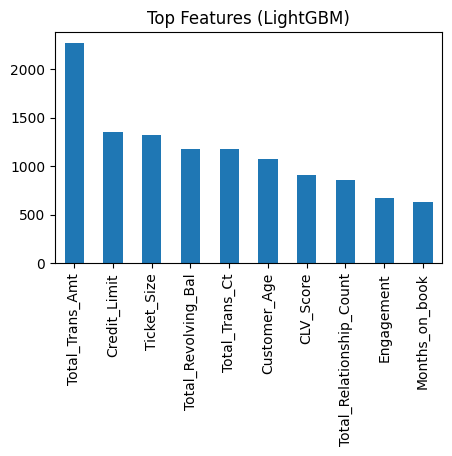

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(5,3))
importance.head(10).plot(kind="bar")
plt.title("Top Features (LightGBM)")
plt.show()

In [32]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

type(shap_values)

c:\Users\91914\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


numpy.ndarray

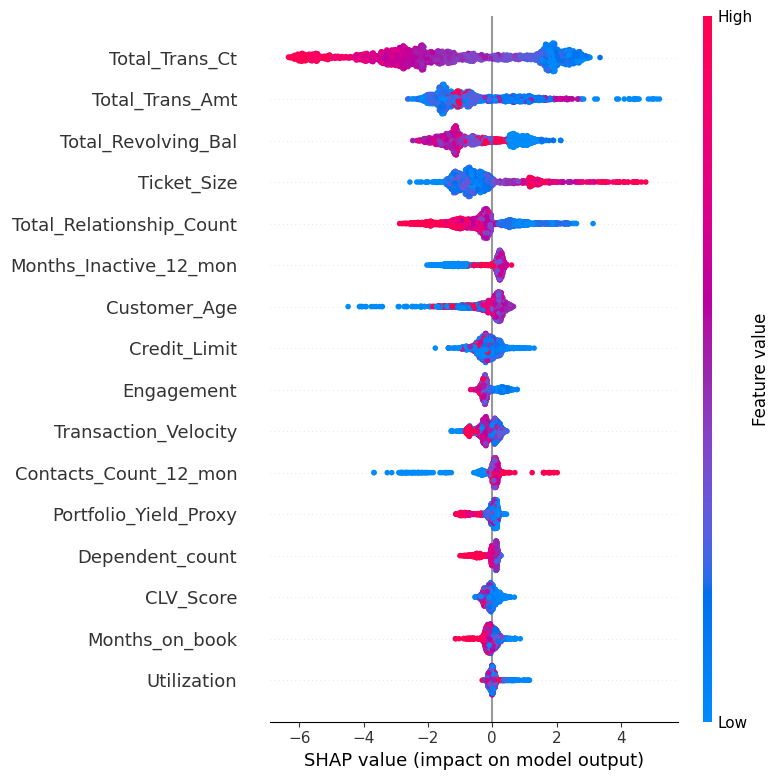

In [31]:
shap.summary_plot(shap_values, X_test)

# **HOW does a feature affect churn?**

# SHAP Dependence Insights

## Key Observations

- Customers with low transaction velocity show a sharp increase in churn probability
- Inactivity beyond 2–3 months strongly drives churn behavior
- Lower engagement levels significantly increase churn risk
- Extreme utilization patterns indicate potential financial stress or disengagement

## Business Interpretation

These behavioral thresholds can be used to trigger retention strategies.

## Decision Rules

- Trigger alert if:
  - Transaction Velocity < 5
  - Months Inactive > 2
  - Engagement Score below threshold

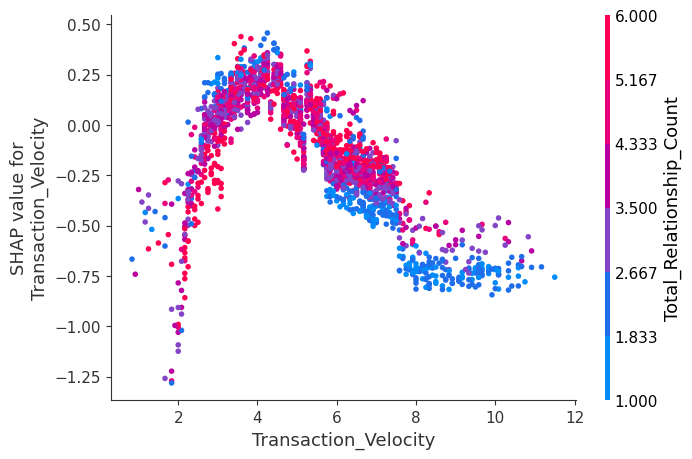

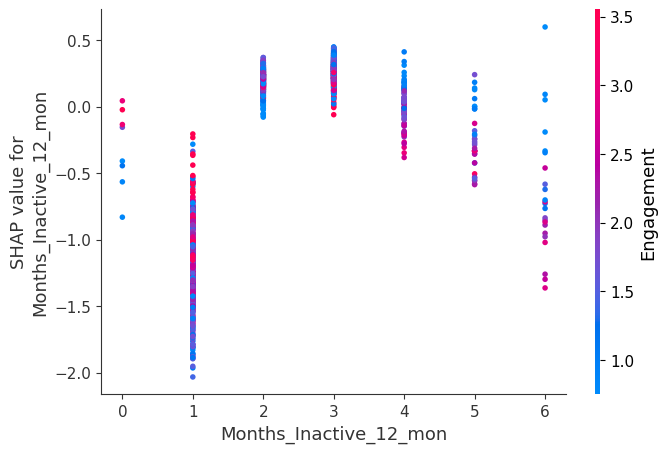

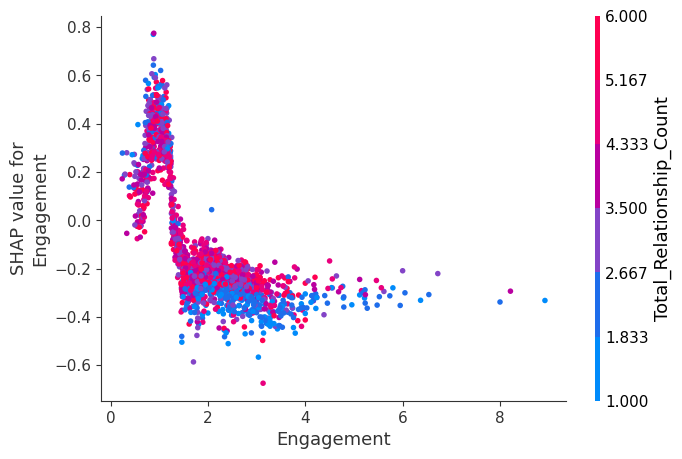

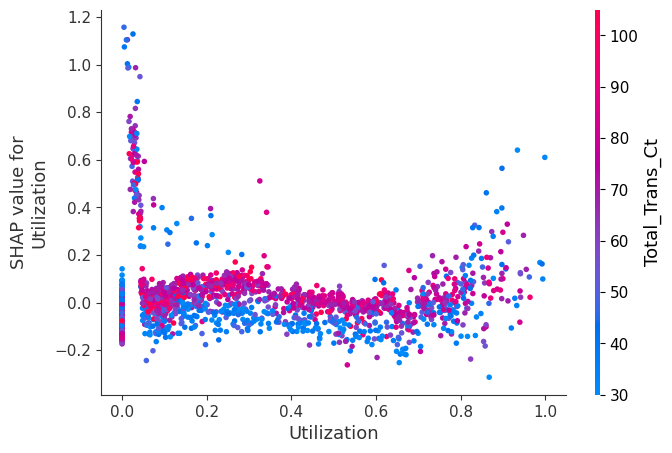

In [ ]:
top_features = [
    "Transaction_Velocity",
    "Months_Inactive_12_mon",
    "Engagement",
    "Utilization"
]

for feature in top_features:
    shap.dependence_plot(feature, shap_values, X_test)

In [14]:
df["Churn_Probability"] = model.predict_proba(X)[:,1]

high_risk = df[df["Churn_Probability"] > 0.7]

high_risk.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Avg_Utilization_Ratio,VIP_Flag,Ticket_Size,Utilization,Engagement,Portfolio_Yield_Proxy,CLV_Score,Transaction_Velocity,Customer_Segment,Churn_Probability
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0.000,0,29.142857,0.000000,1.333333,0.000000,1088.000000,2.333333,Dormant,0.944275
21,1,62,F,0,Graduate,Married,Less than $40K,Blue,49,2,...,0.000,0,43.250000,0.000000,0.326531,0.000000,225.959184,1.333333,Dormant,0.999881
22,0,41,M,3,High School,Married,$40K - $60K,Blue,33,4,...,0.152,0,51.722222,0.152125,0.545455,141.628635,585.070165,1.500000,Dormant,0.861413
37,0,42,F,4,High School,Married,Less than $40K,Gold,36,2,...,0.000,0,43.909091,0.000000,0.611111,0.000000,590.333333,1.833333,Dormant,0.971134
39,1,66,F,0,Doctorate,Married,Not_Disclosed,Blue,56,5,...,0.077,0,44.000000,0.076757,0.285714,54.037046,216.582013,1.333333,Dormant,0.994160


In [16]:
df.to_csv("../dataset/processed/credit_card_lgbm_scored.csv", index=False)
print("Scored dataset saved.")

Scored dataset saved.


# Final Business Insights 

## Answer

High-value customers with declining engagement and transaction activity 
are at the highest risk of churn and represent the largest potential revenue loss.

## Evidence

- LightGBM achieved strong predictive performance (ROC-AUC ~0.98+)
- Key churn drivers:
  - Transaction Velocity ↓
  - Months Inactive ↑
  - Engagement ↓

## Action

Target customers with:
- Transaction_Velocity < 5
- Months_Inactive > 2
- High CLV Score

Recommended strategies:
- Cashback offers
- Rewards boost
- Retention campaigns

## Business Impact

- Reduces churn-driven revenue loss
- Improves retention efficiency
- Enables targeted marketing

## Conclusion

The model bridges the gap between prediction and decision-making,
making it suitable for real-world fintech applications.